# Scam Detection AI - Exploratory Data Analysis

This notebook analyzes the consolidated dataset used across the Scam Detection AI progression. The goal is not only to describe the data, but to justify the major architectural decisions in the project: expanding beyond the original text baseline, moving from DistilBERT to ModernBERT, adding transcript-domain adaptation, and validating a CPU-oriented GGUF inference path.

Key questions answered here:

- Are labels balanced enough to support fair binary classification?
- Why do evaluation and confusion-matrix sample counts differ across stages?
- Do text lengths justify a longer-context model than DistilBERT?
- Is there measurable domain shift between written messages and ASR transcripts?
- Are there obvious data quality or leakage risks to document before final reporting?


In [1]:
import os
from pathlib import Path
from datetime import datetime
import hashlib
import json
import re
import subprocess
import warnings

os.environ.setdefault("MPLCONFIGDIR", str(Path("tmp/matplotlib_cache").resolve()))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

try:
    from transformers.utils import logging as hf_logging
    hf_logging.set_verbosity_error()
except Exception:
    pass

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "semibold"

OUTPUT_DIR = Path("output/eda_plots")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def get_git_commit():
    try:
        return subprocess.check_output(["git", "rev-parse", "HEAD"], text=True).strip()
    except Exception:
        return "unknown"

print("Notebook generated/run at:", datetime.now().isoformat(timespec="seconds"))
print("Git commit:", get_git_commit())


Notebook generated/run at: 2026-08-14T21:07:27
Git commit: a951bfc2c462bd43ea6bc2967ad3ac6eb7b5130a


## 1. Data Loading and Snapshot Context

The project uses DagsHub as the source of truth, while this notebook reads the local cache at `data/collated_for_eda.csv`. The local cache currently combines the available Phase 1/1.5 written splits and Phase 2 ASR transcript data. If DagsHub artifacts are refreshed, rerun `scripts/18_collate_eda_data.py` before rerunning this notebook.

This distinction matters because the project report describes the full stage lineage, while EDA may be run against the latest available local snapshot. The reconciliation table below makes that explicit instead of hiding apparent count differences.


In [2]:
data_path = Path("data/collated_for_eda.csv")
if not data_path.exists():
    raise FileNotFoundError("data/collated_for_eda.csv not found. Run scripts/18_collate_eda_data.py or download the DagsHub artifact first.")

df = pd.read_csv(data_path)
df["text"] = df["text"].astype(str)
df["label"] = df["label"].astype(int)

print(f"Local EDA snapshot path: {data_path}")
print(f"Total samples in local EDA snapshot: {len(df):,}")
print(f"Columns: {list(df.columns)}")
display(df.head())


Local EDA snapshot path: data/collated_for_eda.csv
Total samples in local EDA snapshot: 31,522
Columns: ['text', 'label', 'source_phase']


,text,label,source_phase
0,"hello. hello, this is karen from speedy delive...",0,Phase_1_and_1.5_Written_Text
1,"""your child is in my hands. if you don't want ...",1,Phase_1_and_1.5_Written_Text
2,'i am your transportation consulting assistant...,1,Phase_1_and_1.5_Written_Text
3,"didn't try, g and i decided not to head out",0,Phase_1_and_1.5_Written_Text
4,i know what you want to say.,0,Phase_1_and_1.5_Written_Text


## 2. Dataset Lineage and Evaluation Split Reconciliation

Different confusion matrices have different totals because each stage used a different dataset scope and compute budget. This is deliberate:

- Stage 1 measured the original baseline corpus.
- Stage 1.5 expanded the corpus for broader written-text robustness.
- Stage 2 focused on transcript-domain adaptation.
- Stage 3/4 used a balanced CPU-feasible subset for GGUF-head benchmarking.

The table below connects those counts to the exact evaluation intent.


In [3]:
def label_counts_for(path):
    p = Path(path)
    if not p.exists():
        return {"rows": None, "legitimate": None, "scam": None}
    temp = pd.read_csv(p)
    counts = temp["label"].value_counts().to_dict() if "label" in temp else {}
    return {"rows": len(temp), "legitimate": counts.get(0, 0), "scam": counts.get(1, 0)}

split_paths = {
    "phase1.5_train": "data/phase1.5/train.csv",
    "phase1.5_val": "data/phase1.5/val.csv",
    "phase1.5_test": "data/phase1.5/test.csv",
    "phase2_raw_asr": "data/phase2_asr/raw_asr_transcripts.csv",
    "phase2_ptq_calibration": "data/phase2_asr/ptq_calibration.csv",
}

split_rows = []
for name, path in split_paths.items():
    info = label_counts_for(path)
    split_rows.append({"split": name, "path": path, **info})
split_df = pd.DataFrame(split_rows)
display(split_df)

stage_breakdown = pd.DataFrame([
    {
        "stage": "Stage 1 - DistilBERT",
        "data_scope": "Original baseline SMS/email corpus",
        "evaluation_count": 5472,
        "matrix_sum_check": "2049 + 33 + 21 + 3369 = 5472",
        "reason": "Initial held-out baseline before broad data expansion",
    },
    {
        "stage": "Stage 1.5 - ModernBERT",
        "data_scope": "Expanded universal written corpus",
        "evaluation_count": 5748,
        "matrix_sum_check": "2927 + 6 + 34 + 2781 = 5748",
        "reason": "Larger test set after ingesting heterogeneous written data",
    },
    {
        "stage": "Stage 2 - ASR transcripts",
        "data_scope": "Spoken/ASR transcript adaptation set",
        "evaluation_count": "~1000 transcript holdout",
        "matrix_sum_check": "Logged as transcript validation metrics",
        "reason": "Enough transcript data to measure written-to-spoken domain bridging",
    },
    {
        "stage": "Stage 3/4 - GGUF head",
        "data_scope": "Balanced subset from Stage 1.5 test source",
        "evaluation_count": 500,
        "matrix_sum_check": "246 + 4 + 3 + 247 = 500",
        "reason": "CPU-feasible benchmark for edge latency and quality",
    },
])
display(stage_breakdown)


,split,path,rows,legitimate,scam
0,phase1.5_train,data/phase1.5/train.csv,20113,10018,10095
1,phase1.5_val,data/phase1.5/val.csv,2873,1416,1457
2,phase1.5_test,data/phase1.5/test.csv,5748,2933,2815
3,phase2_raw_asr,data/phase2_asr/raw_asr_transcripts.csv,2788,1394,1394
4,phase2_ptq_calibration,data/phase2_asr/ptq_calibration.csv,279,140,139


,stage,data_scope,evaluation_count,matrix_sum_check,reason
0,Stage 1 - DistilBERT,Original baseline SMS/email corpus,5472,2049 + 33 + 21 + 3369 = 5472,Initial held-out baseline before broad data ex...
1,Stage 1.5 - ModernBERT,Expanded universal written corpus,5748,2927 + 6 + 34 + 2781 = 5748,Larger test set after ingesting heterogeneous ...
2,Stage 2 - ASR transcripts,Spoken/ASR transcript adaptation set,~1000 transcript holdout,Logged as transcript validation metrics,Enough transcript data to measure written-to-s...
3,Stage 3/4 - GGUF head,Balanced subset from Stage 1.5 test source,500,246 + 4 + 3 + 247 = 500,CPU-feasible benchmark for edge latency and qu...


## 3. Label Balance by Phase

Balanced labels reduce the risk that high accuracy is only reflecting class imbalance. The current EDA snapshot is perfectly balanced overall and balanced within each phase.


,Legitimate,Scam
source_phase,,
Phase_1_and_1.5_Written_Text,14367,14367
Phase_2_Spoken_ASR_Transcripts,1394,1394


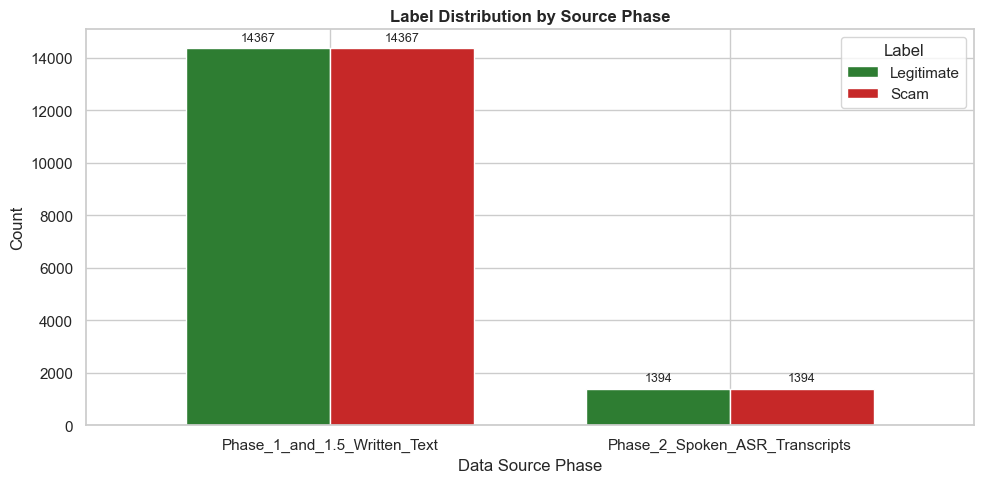

In [4]:
phase_label = pd.crosstab(df["source_phase"], df["label"])
phase_label.columns = ["Legitimate", "Scam"]
display(phase_label)

ax = phase_label.plot(kind="bar", figsize=(10, 5), color=["#2E7D32", "#C62828"], width=0.72)
ax.set_title("Label Distribution by Source Phase")
ax.set_xlabel("Data Source Phase")
ax.set_ylabel("Count")
ax.legend(title="Label")
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    labels = [f"{int(v)}" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "label_balance_clean.png", dpi=300)
plt.show()


## 4. Missing Values, Duplicates, and Leakage Checks

This section catches basic data quality issues before model training. Duplicate texts are not automatically wrong in scam/spam datasets, but they should be known and controlled. Split overlap is especially important because duplicated text across train/validation/test would inflate evaluation metrics.


In [5]:
quality = pd.DataFrame({
    "column": df.columns,
    "missing_count": [df[c].isna().sum() for c in df.columns],
    "missing_pct": [df[c].isna().mean() * 100 for c in df.columns],
})
display(quality)

def normalize_text(text):
    return re.sub(r"\s+", " ", str(text).strip().lower())

df["normalized_text"] = df["text"].apply(normalize_text)
df["text_hash"] = df["normalized_text"].apply(lambda x: hashlib.sha256(x.encode("utf-8")).hexdigest())

dup_summary = pd.DataFrame([
    {"scope": "overall", "duplicate_rows": int(df.duplicated("text_hash").sum()), "unique_texts": int(df["text_hash"].nunique())}
])
display(dup_summary)

dup_by_phase = df.groupby("source_phase").apply(lambda x: pd.Series({
    "rows": len(x),
    "duplicate_rows": int(x.duplicated("text_hash").sum()),
    "unique_texts": int(x["text_hash"].nunique()),
})).reset_index()
display(dup_by_phase)

# Phase 1.5 split leakage check, if split files are available locally.
split_hashes = {}
for split, path in {"train": "data/phase1.5/train.csv", "val": "data/phase1.5/val.csv", "test": "data/phase1.5/test.csv"}.items():
    p = Path(path)
    if p.exists():
        temp = pd.read_csv(p)
        hashes = set(temp["text"].astype(str).map(normalize_text).map(lambda x: hashlib.sha256(x.encode("utf-8")).hexdigest()))
        split_hashes[split] = hashes

leakage_rows = []
for a, b in [("train", "val"), ("train", "test"), ("val", "test")]:
    if a in split_hashes and b in split_hashes:
        leakage_rows.append({"split_pair": f"{a} vs {b}", "overlap_count": len(split_hashes[a] & split_hashes[b])})
if leakage_rows:
    display(pd.DataFrame(leakage_rows))
else:
    print("Phase 1.5 split files not available locally; split leakage check skipped.")


,column,missing_count,missing_pct
0,text,0,0.0
1,label,0,0.0
2,source_phase,0,0.0


,scope,duplicate_rows,unique_texts
0,overall,663,30859


,source_phase,rows,duplicate_rows,unique_texts
0,Phase_1_and_1.5_Written_Text,28734,0,28734
1,Phase_2_Spoken_ASR_Transcripts,2788,663,2125


,split_pair,overlap_count
0,train vs val,0
1,train vs test,0
2,val vs test,0


## 5. Text Length Distribution: Word Count and Tokenizer Count

Word count is useful for intuition, but transformer limits are measured in tokens. This notebook computes word counts for every sample and attempts tokenizer-based counts for DistilBERT and ModernBERT using locally cached tokenizers. If a tokenizer is unavailable offline, the cell prints a clear note and continues with the word-count analysis.


count        mean         std   min  \
source_phase                   label                                          
Phase_1_and_1.5_Written_Text   0      14367.0  480.517993  781.336589   1.0   
                               1      14367.0  282.942368  288.595652   2.0   
Phase_2_Spoken_ASR_Transcripts 0       1394.0   16.845050   11.350531   6.0   
                               1       1394.0   60.504304   49.124105  11.0   

                                        50%    75%     90%     95%     99%  \
source_phase                   label                                         
Phase_1_and_1.5_Written_Text   0       39.0  478.0  1936.4  2224.0  2615.0   
                               1      232.0  375.0   531.0   659.0  1139.0   
Phase_2_Spoken_ASR_Transcripts 0       13.0   22.0    33.0    41.0    54.0   
                               1       53.0   70.0    88.0   111.0   174.0   

                                         max  
source_phase                   label          
Phase_1_and_1.5_Written_Text   0      3542.0  
                               1      9612.0  
Phase_2_Spoken_ASR_Transcripts 0        74.0  
                               1      1389.0

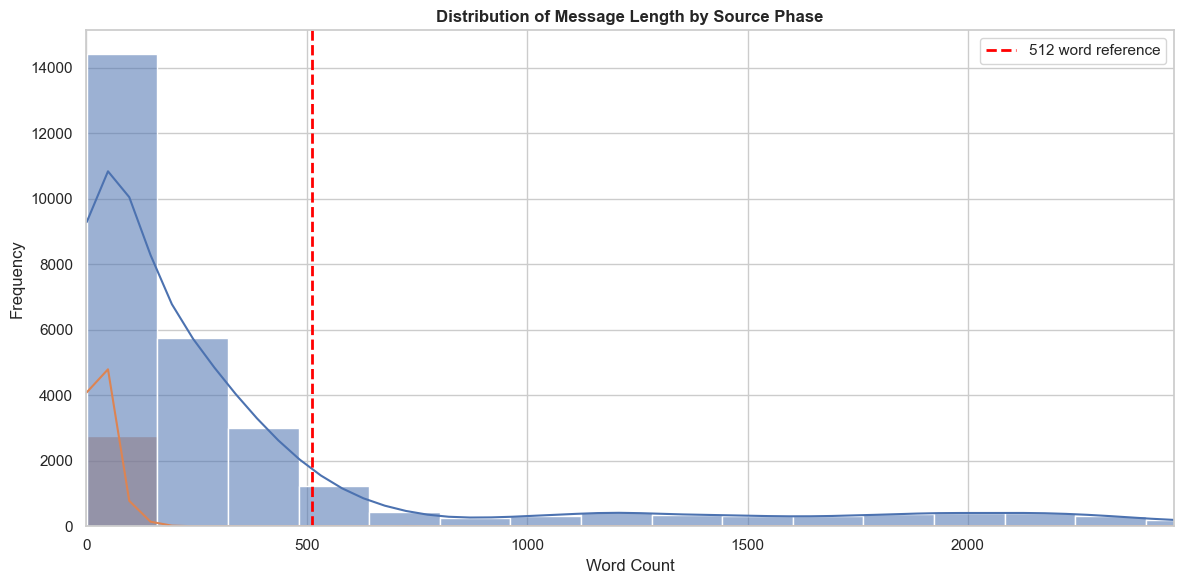

,source_phase,pct_over_512_words,pct_over_2048_words,max_words
0,Phase_1_and_1.5_Written_Text,18.023944,4.193638,9612
1,Phase_2_Spoken_ASR_Transcripts,0.071736,0.000000,1389


In [6]:
df["word_count"] = df["text"].str.split().str.len()
length_summary = df.groupby(["source_phase", "label"])["word_count"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
display(length_summary)

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x="word_count", hue="source_phase", bins=60, kde=True, alpha=0.55)
plt.axvline(x=512, color="red", linestyle="--", linewidth=2, label="512 word reference")
plt.title("Distribution of Message Length by Source Phase")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.xlim(0, max(1000, df["word_count"].quantile(0.99)))
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "word_count_distribution.png", dpi=300)
plt.show()

threshold_rows = []
for phase, part in df.groupby("source_phase"):
    threshold_rows.append({
        "source_phase": phase,
        "pct_over_512_words": (part["word_count"] > 512).mean() * 100,
        "pct_over_2048_words": (part["word_count"] > 2048).mean() * 100,
        "max_words": int(part["word_count"].max()),
    })
display(pd.DataFrame(threshold_rows))


In [7]:
def add_token_lengths(model_name, column_name, sample_size=5000):
    try:
        from transformers import AutoTokenizer
        tokenizer = AutoTokenizer.from_pretrained(model_name, local_files_only=True)
        # Silence max-length warnings: here we are measuring length, not feeding the model.
        tokenizer.model_max_length = int(1e9)
    except Exception as exc:
        print(f"Tokenizer unavailable locally for {model_name}: {exc}")
        return False

    sample_idx = df.sample(min(sample_size, len(df)), random_state=42).index
    lengths = []
    for text in df.loc[sample_idx, "text"]:
        encoded = tokenizer(str(text), add_special_tokens=True, truncation=False, return_attention_mask=False)
        lengths.append(len(encoded["input_ids"]))
    df.loc[sample_idx, column_name] = lengths
    print(f"Computed {column_name} for {len(sample_idx):,} sampled rows using {model_name}.")
    return True

has_distil = add_token_lengths("distilbert-base-uncased", "distilbert_tokens")
has_modern = add_token_lengths("answerdotai/ModernBERT-base", "modernbert_tokens")

available_token_cols = [c for c in ["distilbert_tokens", "modernbert_tokens"] if c in df and df[c].notna().any()]
if available_token_cols:
    token_summary = []
    for col in available_token_cols:
        temp = df[df[col].notna()].copy()
        token_summary.append({
            "tokenizer": col,
            "sampled_rows": int(temp[col].notna().sum()),
            "pct_over_512_tokens": float((temp[col] > 512).mean() * 100),
            "pct_over_8192_tokens": float((temp[col] > 8192).mean() * 100),
            "p95_tokens": float(temp[col].quantile(0.95)),
            "max_tokens": int(temp[col].max()),
        })
    display(pd.DataFrame(token_summary))
else:
    print("No local tokenizers were available. Use the word-count plots above as directional evidence and rerun this cell in the Kaggle/HF environment with cached tokenizers.")


Computed distilbert_tokens for 5,000 sampled rows using distilbert-base-uncased.
Tokenizer unavailable locally for answerdotai/ModernBERT-base: We couldn't connect to 'https://huggingface.co' to load the files, and couldn't find them in the cached files.
Check your internet connection or see how to run the library in offline mode at 'https://huggingface.co/docs/transformers/installation#offline-mode'.


,tokenizer,sampled_rows,pct_over_512_tokens,pct_over_8192_tokens,p95_tokens,max_tokens
0,distilbert_tokens,5000,20.82,0.02,2445.1,8362


## 6. Domain Shift: Normalized Conversational Marker Analysis

Raw filler counts can be biased by message length, so this section reports conversational markers per 100 words. Strict fillers (`uh`, `um`, `hmm`, `ah`) are tracked separately from looser conversational markers (`like`, `so`, `yeah`, `okay`, `hi`, `hello`) because the looser set can also appear in normal written text.


strict_disfluency_count                      \
                                                 count      mean       std   
source_phase                                                                 
Phase_1_and_1.5_Written_Text                   28734.0  2.565985  9.983752   
Phase_2_Spoken_ASR_Transcripts                  2788.0  0.001076  0.056817   

                                                                       ...  \
                                min  50%  75%  90%   95%   99%    max  ...   
source_phase                                                           ...   
Phase_1_and_1.5_Written_Text    0.0  0.0  0.0  4.0  16.0  55.0  135.0  ...   
Phase_2_Spoken_ASR_Transcripts  0.0  0.0  0.0  0.0   0.0   0.0    3.0  ...   

                               conversation_markers_per_100_words            \
                                                            count      mean   
source_phase                                                                  
Phase_1_and_1.5_Written_Text                              28734.0  2.339608   
Phase_2_Spoken_ASR_Transcripts                             2788.0  2.698533   

                                                                             \
                                     std  min       50%       75%       90%   
source_phase                                                                  
Phase_1_and_1.5_Written_Text    2.576693  0.0  1.910828  3.225806  4.869153   
Phase_2_Spoken_ASR_Transcripts  4.028746  0.0  1.459932  3.703704  8.333333   

                                                                 
                                     95%        99%         max  
source_phase                                                     
Phase_1_and_1.5_Written_Text     6.25000  11.111111  100.000000  
Phase_2_Spoken_ASR_Transcripts  11.68552  16.666667   28.571429  

[2 rows x 50 columns]

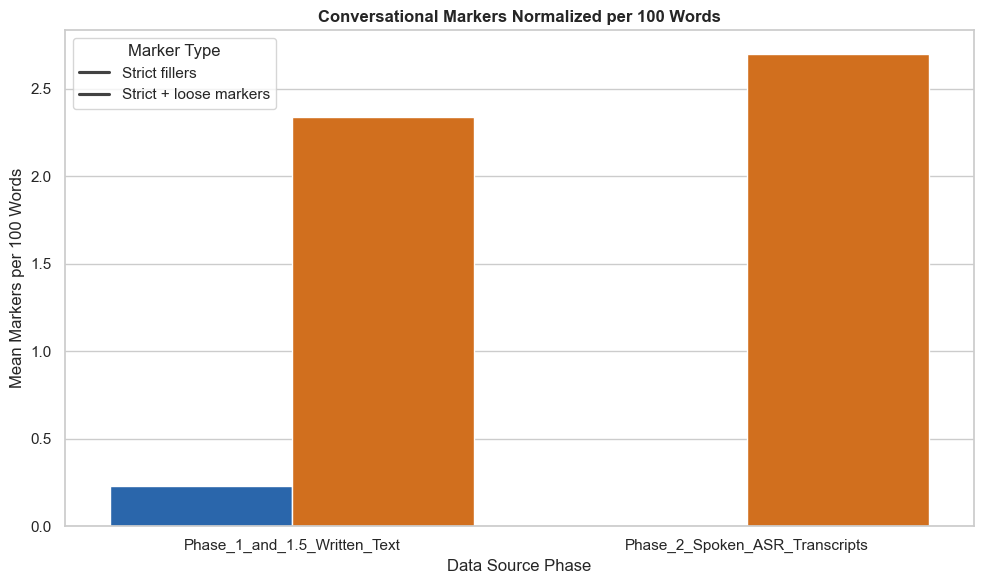

,source_phase,label,word_count,strict_disfluency_count,loose_marker_count,conversation_markers_per_100_words,text
24434,Phase_1_and_1.5_Written_Text,0,1,0,1,100.000000,"hello,"
19351,Phase_1_and_1.5_Written_Text,0,10,0,8,80.000000,hi happy birthday. hi hi hi hi hi hi hi
10493,Phase_1_and_1.5_Written_Text,0,4,1,1,50.000000,okay... we wait ah
7589,Phase_1_and_1.5_Written_Text,0,8,0,4,50.000000,please don't say like that. hi hi hi
10946,Phase_1_and_1.5_Written_Text,0,8,0,4,50.000000,please dont say like that. hi hi hi
31172,Phase_2_Spoken_ASR_Transcripts,0,7,0,2,28.571429,hi I'd like to deposit money please
30667,Phase_2_Spoken_ASR_Transcripts,0,7,0,2,28.571429,hi I'd like to pay bill please
30631,Phase_2_Spoken_ASR_Transcripts,0,7,0,2,28.571429,hello I would like to take alone
30339,Phase_2_Spoken_ASR_Transcripts,0,8,0,2,25.000000,hello I would like to change my address
30321,Phase_2_Spoken_ASR_Transcripts,0,8,0,2,25.000000,hello I like to change my address please


In [8]:
STRICT_FILLERS = r"\b(uh|um|hmm|ah)\b"
LOOSE_MARKERS = r"\b(like|so|yeah|okay|hi|hello)\b"

def count_pattern(text, pattern):
    return len(re.findall(pattern, str(text).lower()))

df["strict_disfluency_count"] = df["text"].apply(lambda x: count_pattern(x, STRICT_FILLERS))
df["loose_marker_count"] = df["text"].apply(lambda x: count_pattern(x, LOOSE_MARKERS))
df["all_conversation_markers"] = df["strict_disfluency_count"] + df["loose_marker_count"]
df["strict_disfluencies_per_100_words"] = df["strict_disfluency_count"] / df["word_count"].clip(lower=1) * 100
df["conversation_markers_per_100_words"] = df["all_conversation_markers"] / df["word_count"].clip(lower=1) * 100

summary = df.groupby("source_phase")[[
    "strict_disfluency_count",
    "loose_marker_count",
    "all_conversation_markers",
    "strict_disfluencies_per_100_words",
    "conversation_markers_per_100_words",
]].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
display(summary)

marker_means = df.groupby("source_phase")[["strict_disfluencies_per_100_words", "conversation_markers_per_100_words"]].mean().reset_index()
marker_long = marker_means.melt(id_vars="source_phase", var_name="marker_type", value_name="mean_per_100_words")

plt.figure(figsize=(10, 6))
sns.barplot(data=marker_long, x="source_phase", y="mean_per_100_words", hue="marker_type", palette=["#1565C0", "#EF6C00"])
plt.title("Conversational Markers Normalized per 100 Words")
plt.xlabel("Data Source Phase")
plt.ylabel("Mean Markers per 100 Words")
plt.legend(title="Marker Type", labels=["Strict fillers", "Strict + loose markers"])
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "normalized_conversation_markers.png", dpi=300)
plt.show()

top_examples = df.sort_values("conversation_markers_per_100_words", ascending=False).groupby("source_phase").head(5)[
    ["source_phase", "label", "word_count", "strict_disfluency_count", "loose_marker_count", "conversation_markers_per_100_words", "text"]
]
display(top_examples)


## 7. Top N-Grams by Label

A quick TF-IDF inspection makes the learned problem more interpretable. Scam-heavy terms should reflect urgency, account/security language, payment pressure, suspicious links, or credential prompts; legitimate terms should reflect routine support or account-service phrasing.


,term,score_diff,more_associated_with
0,huh,0.025735,Legitimate
1,lot,0.020624,Legitimate
2,laughter,0.017647,Legitimate
3,people,0.017184,Legitimate
4,got,0.015608,Legitimate
5,things,0.012939,Legitimate
6,good,0.011913,Legitimate
7,went,0.011064,Legitimate
8,insurance,0.010664,Legitimate
9,school,0.010483,Legitimate


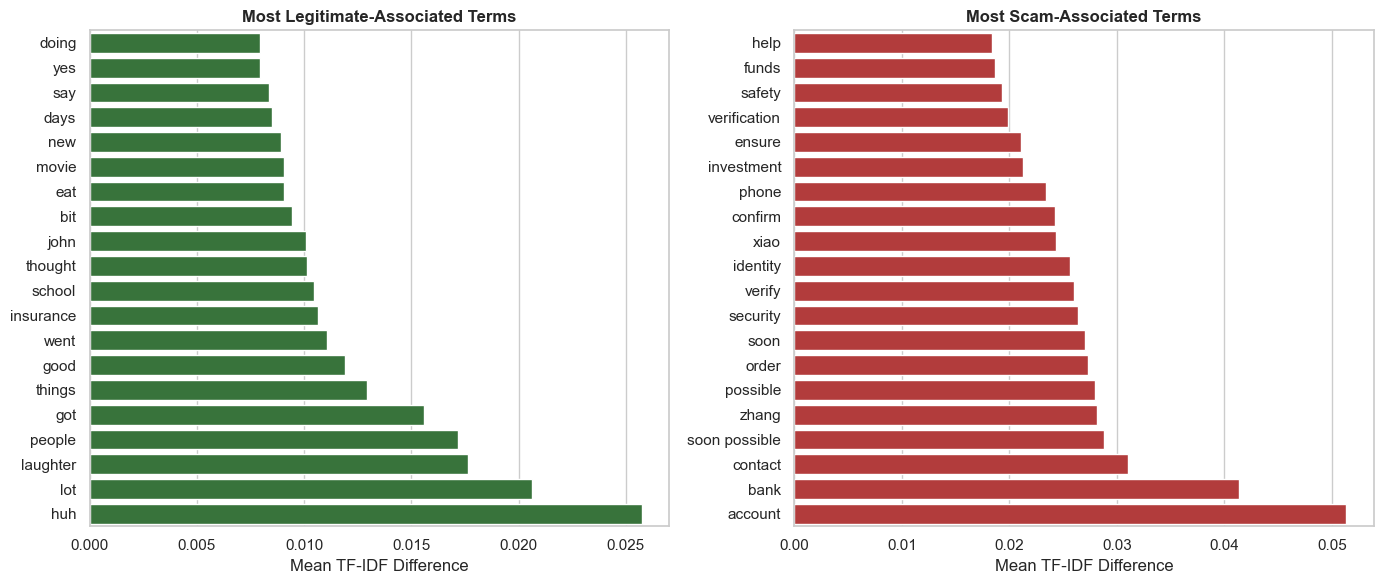

In [9]:
CUSTOM_STOPWORDS = set(ENGLISH_STOP_WORDS) | {
    "uh", "um", "hmm", "ah", "like", "so", "yeah", "okay", "hi", "hello", "thanks", "thank",
    "just", "know", "think", "right", "really", "don", "want", "going", "ll", "ve", "im", "ive",
    "customer", "service", "information", "number", "time", "need", "provide", "understand",
}

def discriminative_terms(n=20, max_features=8000):
    vectorizer = TfidfVectorizer(
        stop_words=list(CUSTOM_STOPWORDS),
        ngram_range=(1, 2),
        max_features=max_features,
        min_df=5,
        token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]{2,}\b",
    )
    X = vectorizer.fit_transform(df["text"].astype(str))
    terms = np.array(vectorizer.get_feature_names_out())
    labels = df["label"].to_numpy()
    legit_mean = np.asarray(X[labels == 0].mean(axis=0)).ravel()
    scam_mean = np.asarray(X[labels == 1].mean(axis=0)).ravel()
    diff = scam_mean - legit_mean
    scam_idx = diff.argsort()[::-1][:n]
    legit_idx = diff.argsort()[:n]
    scam_terms = pd.DataFrame({"term": terms[scam_idx], "score_diff": diff[scam_idx], "more_associated_with": "Scam"})
    legit_terms = pd.DataFrame({"term": terms[legit_idx], "score_diff": -diff[legit_idx], "more_associated_with": "Legitimate"})
    return legit_terms, scam_terms

legit_terms, scam_terms = discriminative_terms()
display(pd.concat([legit_terms, scam_terms]))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, data, title, color in [
    (axes[0], legit_terms.sort_values("score_diff"), "Most Legitimate-Associated Terms", "#2E7D32"),
    (axes[1], scam_terms.sort_values("score_diff"), "Most Scam-Associated Terms", "#C62828"),
]:
    sns.barplot(data=data, x="score_diff", y="term", ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel("Mean TF-IDF Difference")
    ax.set_ylabel("")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "discriminative_tfidf_terms_by_label.png", dpi=300)
plt.show()


## 8. EDA Takeaways

- The current EDA snapshot is balanced overall and within both written and ASR phases.
- The split reconciliation explains why confusion matrices differ in size across stages.
- Length analysis supports the architectural move from DistilBERT to ModernBERT for long, heterogeneous inputs.
- Normalized disfluency analysis provides evidence for transcript-domain adaptation rather than treating ASR text as ordinary written text.
- Duplicate and split-overlap checks should be rerun whenever DagsHub data artifacts are refreshed.

Recommended future extension: add an embedding-space visualization, such as PCA/UMAP over ModernBERT embeddings, to show separation between written and ASR transcript domains.
